In [1]:
import torch
import sys, os
import math as mt

src_dir = os.path.join(os.path.abspath(''), '..')  # goes up from models/ to src/
configs_dir = os.path.join(os.path.abspath(''), '../..')
sys.path.insert(0, os.path.abspath(src_dir))
sys.path.insert(0, os.path.abspath(configs_dir))

In [2]:
from models.autoencoder import Autoencoder
from models.autoencoder import trainSAE, testSAE
from utils.data_loading import QMatrixData
import importlib
import evaluation.student_eval as student_eval

K = 5
lr = 5e-4
train_epochs = 500
in_channels = 4 
num_channels = 10
kernel_dim = 2
maze_dim = 4
batch_size = 10
gamma_sparse = 1/20*mt.sqrt(maze_dim**2*in_channels/K)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import numpy as np
import random
seed = 39
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [4]:
BASE_DIR = os.path.abspath(os.path.join(os.path.abspath(''), '..', '..', '..'))

train_dataset = QMatrixData(
    q_file_path=os.path.join(BASE_DIR, "data/teacher/q matrix dictionaries/q_matricestraining_4x4.pkl"),
    label_file_path=os.path.join(BASE_DIR, "data/teacher/label dictionaries/q_matrices_labelstraining_4x4.pkl")
)
test_dataset = QMatrixData(
    q_file_path=os.path.join(BASE_DIR, "data/teacher/q matrix dictionaries/q_matricestest_4x4.pkl"),
    label_file_path=os.path.join(BASE_DIR, "data/teacher/label dictionaries/q_matrices_labelstest_4x4.pkl")
)

autoencoder = Autoencoder(in_channels, maze_dim, num_channels, kernel_dim, K)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=lr)

# training language
total_losses, recon_losses, sparsity_losses, all_messages = trainSAE(autoencoder, train_dataset, gamma_sparse, optimizer, batch_size, train_epochs, device)

In [5]:
import models.autoencoder
importlib.reload(models.autoencoder)

# getting messages from trained language
_, _, _, all_messages, message_dict = testSAE(autoencoder, train_dataset, batch_size, gamma_sparse, device)

In [6]:
from configs.experiment_config import ExperimentConfig
# Import the specific helper functions from your teacher module
from rl.teacher import (
    generate_q_matrices, 
    make_gridworld_env, 
    compute_perfect_qdict_gridworld
)
from evaluation.student_eval import train_student, run_evaluations

config = ExperimentConfig()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Define where your data is stored (ensure this path exists)
data_dir = "../../../data/teacher" 

# 2. Pass the required arguments: make_env, compute_perfect_qdict, and data_dir
q_matrices, label_dict, wall_state_dict, sopt_dict = generate_q_matrices(
    config, 
    device, 
    make_gridworld_env,              # The 'make_env' argument
    compute_perfect_qdict_gridworld, # The 'compute_perfect_qdict' argument
    data_dir                         # The 'data_dir' argument
)

# Now call the student training with the compatible dictionary
student = train_student(
    label_dict, 
    wall_state_dict, 
    sopt_dict, 
    message_dict,
    config, 
    device, 
    make_gridworld_env,
    num_eps=750
)

Completed calculation of deterministic Q-matrices
Precomputing task environments...


Precomputing tasks: 100%|██████████| 225/225 [00:02<00:00, 83.74it/s]


Training student on 225 tasks...


Student epochs:   7%|▋         | 50/750 [00:15<03:24,  3.42it/s]

    Epoch 50/750 complete


...

    Epoch 650/750 complete


Student epochs:  93%|█████████▎| 700/750 [05:15<00:21,  2.34it/s]

    Epoch 700/750 complete


Student epochs: 100%|██████████| 750/750 [05:41<00:00,  2.19it/s]

    Epoch 750/750 complete


In [7]:
# Ensure all messages are on the correct device first to avoid mid-loop crashes
message_dict_device = {k: v.to(device) for k, v in message_dict.items()}

informed_rates, misinformed_rates = run_evaluations(
    student, 
    label_dict, 
    wall_state_dict, 
    message_dict_device,
    sopt_dict, 
    config, 
    device,
    make_gridworld_env
)

Informed student:     64.12%
Misinformed student: 38.07%


In [8]:
import evaluation.student_eval
importlib.reload(evaluation.student_eval)
from evaluation.student_eval import train_student_with_feedback

autoencoder, student = train_student_with_feedback(
    label_dict, 
    wall_state_dict, 
    sopt_dict, 
    q_matrices, 
    autoencoder, 
    student, 
    config, 
    device,
    make_gridworld_env,
    n_transition_samples=1,
    num_eps=750
)

Precomputing task environments...


Precomputing tasks: 100%|██████████| 225/225 [00:03<00:00, 62.36it/s]


Joint training on 225 tasks...


Joint training epochs:   7%|▋         | 50/750 [01:21<16:28,  1.41s/it]

    Epoch 50/750 completed


...

    Epoch 650/750 completed


Joint training epochs:  93%|█████████▎| 700/750 [13:04<00:51,  1.03s/it]

    Epoch 700/750 completed


Joint training epochs: 100%|██████████| 750/750 [13:44<00:00,  1.10s/it]

    Epoch 750/750 completed


In [9]:
# Extract the optimized messages generated by the newly trained Autoencoder
message_dict_feedback = {}
autoencoder.eval()
with torch.no_grad():
    for task, (wall_label, init_state, goal_state) in label_dict.items():
        q_mat = q_matrices[task].unsqueeze(0).to(device)
        message, _ = autoencoder(q_mat)
        message_dict_feedback[(wall_label, init_state, goal_state)] = message.squeeze(0).detach()

In [10]:
informed_rates, misinformed_rates = run_evaluations(
    student, label_dict, wall_state_dict, message_dict_feedback, sopt_dict, config, device, make_gridworld_env
)

Informed student:     82.30%
Misinformed student: 36.55%


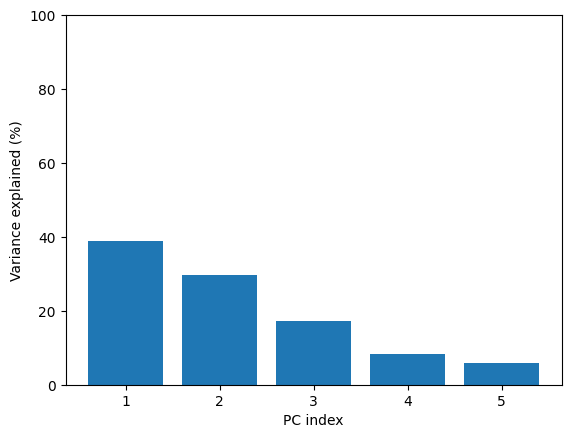

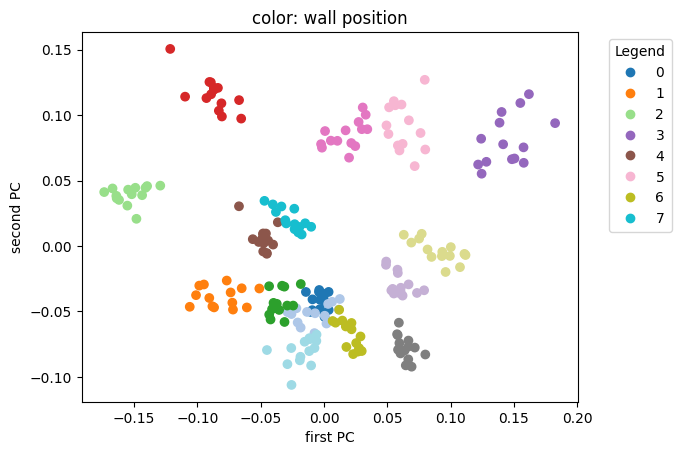

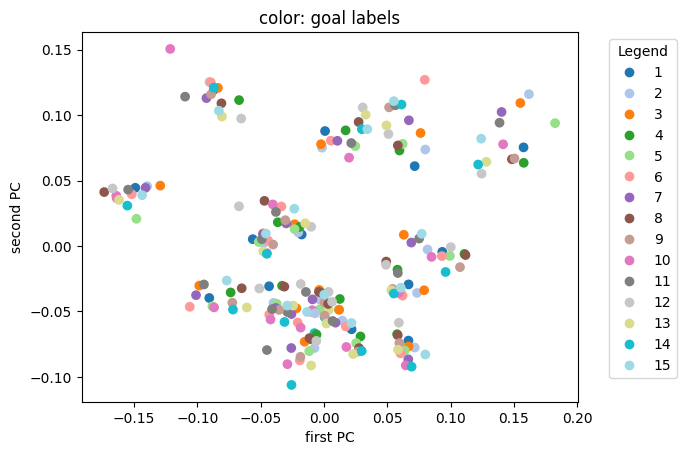

In [11]:
from sklearn.decomposition import PCA
from utils.plotting import plot_pca_variance, plot_pca_by_label

# Stack all messages into a single tensor
messages = torch.cat(all_messages, dim=0)  # shape: (num_tasks, K)
messages_np = messages.numpy()

wall_labels = [train_dataset.labels[i][0] for i in range(225)]
goal_labels = [train_dataset.labels[i][2] for i in range(225)]

pca = PCA(n_components=5)
pca_result = pca.fit_transform(messages_np)

# get plots
plot_pca_variance(pca)
plot_pca_by_label(pca_result, wall_labels, "color: wall position")
plot_pca_by_label(pca_result, goal_labels, "color: goal labels")

In [12]:
from rl.teacher import q_matrix_from_network
import torch.nn as nn

softy = nn.Softmax(dim=0)
student_first_action_indices = []

student.eval()
autoencoder.eval()

with torch.no_grad():
    for i in range(225):
        # 1. Get task parameters (wall_idx, init_state, goal_state)
        task_params = train_dataset.labels[i]
        wall_idx, init_state, goal_state = task_params
        
        # 2. Instantiate the environment for this specific task
        env = make_gridworld_env(task_params, wall_state_dict, config)
        
        # 3. Get the message and wall representation
        msg = message_dict_feedback[(wall_idx, init_state, goal_state)].to(device)
        wall_s = wall_state_dict[wall_idx]
        
        # 4. Generate the Q-matrix using the student network and the specific env
        q_mat = q_matrix_from_network(student, msg, wall_s, config, device, env).cpu()
        
        # 5. Extract first action at the starting position
        row, col = divmod(init_state, 4)
        if q_mat.shape == (4, 4, 4):
            actions_at_start = q_mat[row, col]
        else:
            # Handle flattened (16, 4) Q-matrices
            actions_at_start = q_mat[init_state]
            
        student_first_action_indices.append(torch.argmax(actions_at_start).item())

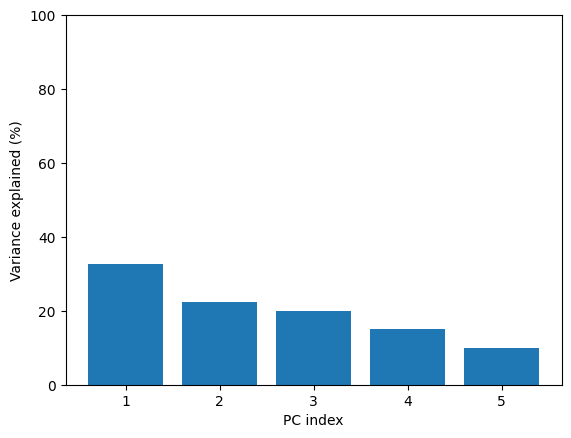

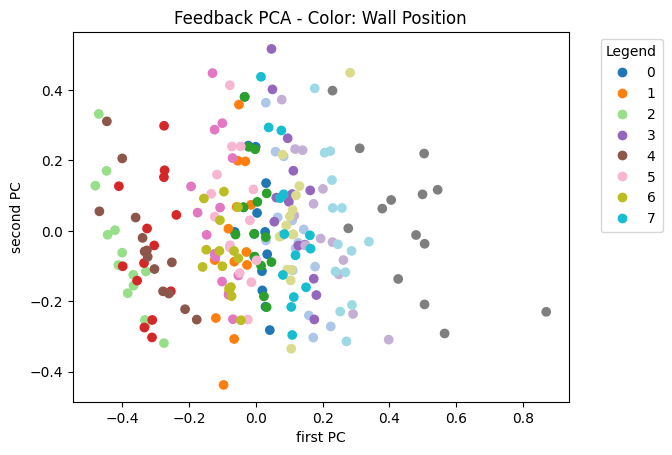

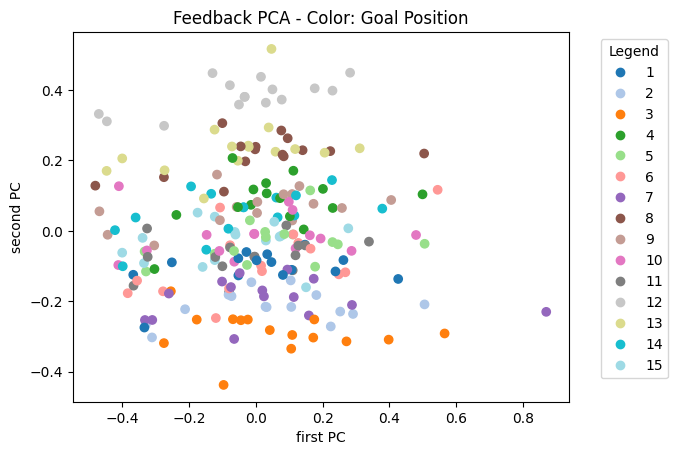

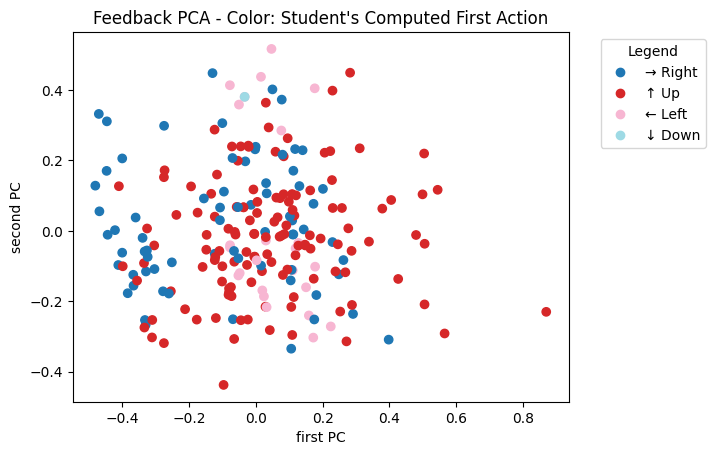

In [13]:
import importlib
import utils.plotting as plotting_utils
importlib.reload(plotting_utils)
from utils.plotting import plot_pca_by_label
import numpy as np
import torch

# --- 1. DATA EXTRACTION & LABEL PREP ---
all_messages_feedback = []
wall_labels = []
goal_labels = []
student_first_action_indices = []

# Ensure model is in eval mode
student.eval()

for i in range(225):
    # Get task parameters (wall_index, init_state, goal_state)
    task_params = train_dataset.labels[i]
    wall_idx, init_state, goal_state = task_params
    
    wall_labels.append(wall_idx)
    goal_labels.append(goal_state)
    
    # --- STUDENT ACTION LOGIC ---
    
    # 1. Instantiate the environment for this specific task
    env = make_gridworld_env(task_params, wall_state_dict, config)
    
    # 2. Get the message and wall representation
    msg = message_dict_feedback[(wall_idx, init_state, goal_state)].to(device)
    wall_s = wall_state_dict[wall_idx]
    
    # 3. Generate the Student's actual Q-matrix from the network
    # We pass the env here to satisfy the function requirements
    with torch.no_grad():
        student_q_mat = q_matrix_from_network(student, msg, wall_s, config, device, env).cpu()
    
    # Identify the actions available at the specific start position
    row, col = divmod(init_state, 4)
    if student_q_mat.shape == (4, 4, 4):
        actions_at_start = student_q_mat[row, col]
    else:
        # If the Q-matrix is flattened to (16, 4)
        actions_at_start = student_q_mat[init_state]
        
    # Get index of student's chosen action (0=Up, 1=Down, 2=Left, 3=Right)
    student_first_action_indices.append(torch.argmax(actions_at_start).item())
    
    # Extract message for PCA fitting
    all_messages_feedback.append(msg.cpu())

# --- 2. PCA PROCESSING ---
messages_feedback_np = torch.stack(all_messages_feedback).cpu().numpy()
pca_fb = PCA(n_components=5)
pca_fb_result = pca_fb.fit_transform(messages_feedback_np)

# --- 3. GENERATE PLOTS ---

# Variance Plot
plot_pca_variance(pca_fb)

# Wall Position Plot
plot_pca_by_label(pca_fb_result, wall_labels, "Feedback PCA - Color: Wall Position")

# Goal Position Plot
plot_pca_by_label(pca_fb_result, goal_labels, "Feedback PCA - Color: Goal Position")

# Student Action Plot (Now with 4-color Arrow Legend)
plot_pca_by_label(
    pca_fb_result, 
    student_first_action_indices, 
    "Feedback PCA - Color: Student's Computed First Action"
)

In [14]:
importlib.reload(student_eval)
from evaluation.student_eval import close_the_loop

student_gen2, student_messages = close_the_loop(
    student, autoencoder, label_dict, wall_state_dict,
    message_dict_feedback, sopt_dict, config, device, make_gridworld_env, num_eps=500
)

--- Closing the Loop: extracting student messages ---
--- Closing the Loop: training 2nd-generation student ---
Precomputing task environments...


Precomputing tasks: 100%|██████████| 225/225 [00:03<00:00, 66.62it/s]


Training student on 225 tasks...


Student epochs:  10%|█         | 50/500 [00:12<01:50,  4.06it/s]

    Epoch 50/500 complete


...

    Epoch 400/500 complete


Student epochs:  90%|█████████ | 450/500 [02:02<00:13,  3.64it/s]

    Epoch 450/500 complete


Student epochs: 100%|██████████| 500/500 [02:19<00:00,  3.57it/s]

    Epoch 500/500 complete


In [15]:
informed_gen2, misinformed_gen2 = student_eval.run_evaluations(
    student_gen2, label_dict, wall_state_dict, student_messages, sopt_dict, config, device, make_gridworld_env
)

Informed student:     75.46%
Misinformed student: 39.93%


In [17]:
# Run additional telephone game iterations starting from gen2
# Each iteration: current student Q-matrices → re-encode → train next student
N_EXTRA = 3  # runs gen3, gen4, gen5

# Seed results table with known values from cells 5, 8, 11
results = {
    'gen':          ['no feedback', 'gen1 (feedback)', 'gen2', 'gen3', 'gen4', 'gen5'],
    'informed':     [55.19, 91.29, 86.54, None, None, None],
    'misinformed':  [39.55, 37.93, 31.97, None, None, None],
}

# Store messages at each generation for PCA analysis
all_messages_by_gen = {
    'gen1 (feedback)': list(message_dict_feedback.values()),
    'gen2': list(student_messages.values()),
}

current_student  = student_gen2
current_messages = student_messages

for i, gen in enumerate(range(3, 3 + N_EXTRA)):
    print(f"\n=== Generation {gen} ===")
    current_student, current_messages = close_the_loop(
        current_student, autoencoder, label_dict, wall_state_dict,
        current_messages, sopt_dict, config, device, make_gridworld_env
    )
    inf, misinf = student_eval.run_evaluations(
        current_student, label_dict, wall_state_dict, current_messages, sopt_dict, config, device, make_gridworld_env
    )
    results['informed'][3 + i]    = round(100 * sum(inf) / len(inf), 2)
    results['misinformed'][3 + i] = round(100 * sum(misinf) / len(misinf), 2)
    all_messages_by_gen[f'gen{gen}'] = list(current_messages.values())


=== Generation 3 ===
--- Closing the Loop: extracting student messages ---
--- Closing the Loop: training 2nd-generation student ---
Precomputing task environments...


Precomputing tasks: 100%|██████████| 225/225 [00:01<00:00, 126.37it/s]


Training student on 225 tasks...


Student epochs:   7%|▋         | 50/750 [00:09<02:42,  4.32it/s]

    Epoch 50/750 complete


...

Student epochs:  93%|█████████▎| 700/750 [02:48<00:22,  2.22it/s]

    Epoch 700/750 complete


Student epochs: 100%|██████████| 750/750 [03:00<00:00,  4.16it/s]

    Epoch 750/750 complete


Informed student:     58.47%
Misinformed student: 37.50%


In [18]:
print(f"{'Condition':<20} {'Informed':>10} {'Misinformed':>13}")
print("-" * 45)
for g, inf, misinf in zip(results['gen'], results['informed'], results['misinformed']):
    print(f"{g:<20} {inf:>9.2f}% {misinf:>12.2f}%")

Condition              Informed   Misinformed
---------------------------------------------
no feedback              55.19%        39.55%
gen1 (feedback)          91.29%        37.93%
gen2                     86.54%        31.97%
gen3                     59.19%        37.69%
gen4                     57.43%        37.06%
gen5                     58.47%        37.50%


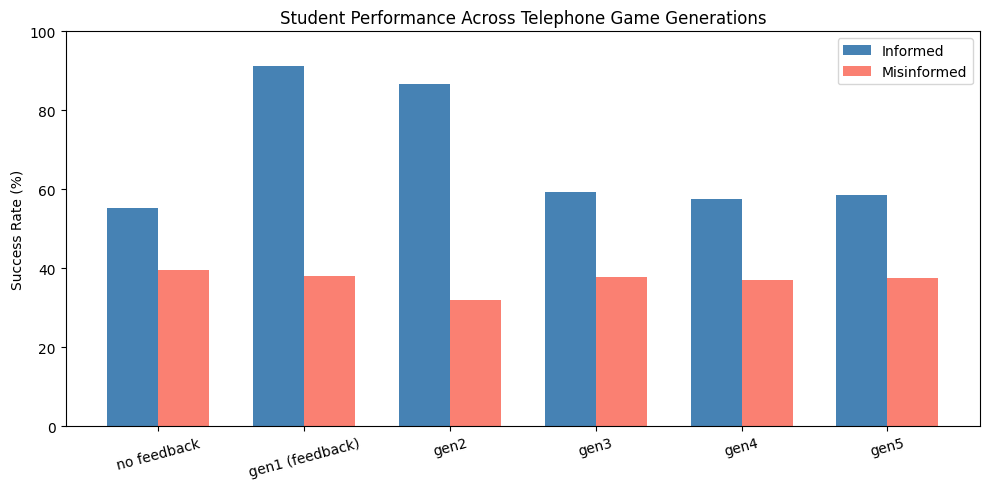

In [19]:
import matplotlib.pyplot as plt
import numpy as np

labels      = results['gen']
informed    = results['informed']
misinformed = results['misinformed']

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, informed,    width, label='Informed',    color='steelblue')
ax.bar(x + width/2, misinformed, width, label='Misinformed', color='salmon')

ax.set_ylabel('Success Rate (%)')
ax.set_title('Student Performance Across Telephone Game Generations')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()

os.makedirs(os.path.join(os.path.abspath(''), '..', '..', '..', 'outputs', 'figures'), exist_ok=True)
_fig_dir = os.path.join(os.path.abspath(''), '..', '..', '..', 'outputs', 'figures')
plt.savefig(os.path.join(_fig_dir, 'fig_telephone_game.png'), bbox_inches='tight', dpi=150)
plt.show()


--- gen1 (feedback) ---


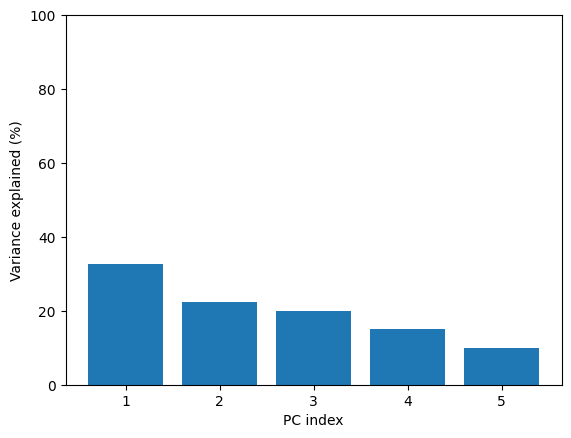

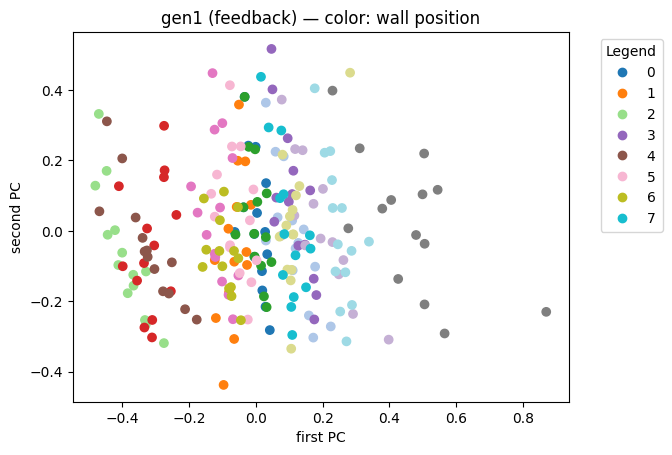

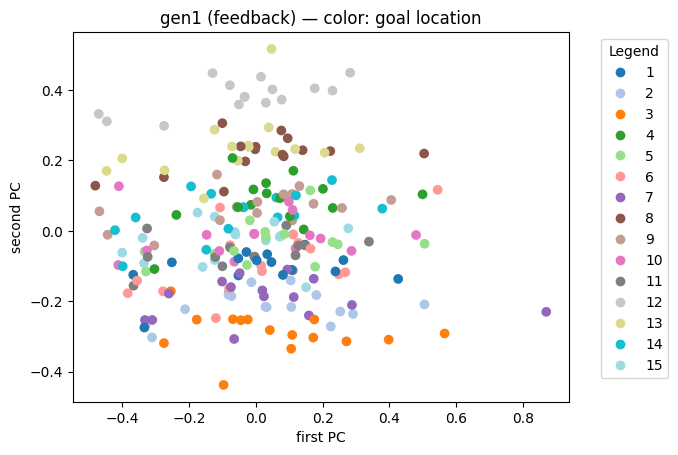


--- gen2 ---


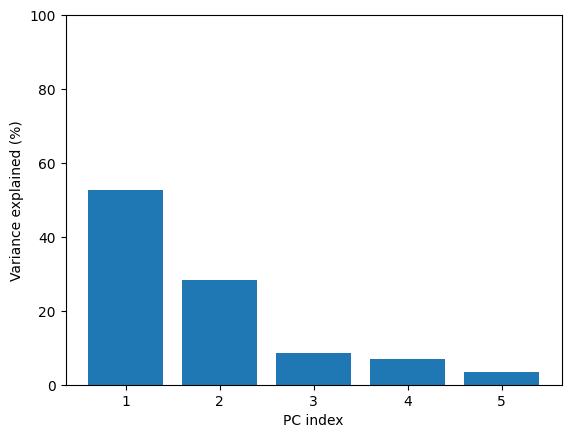

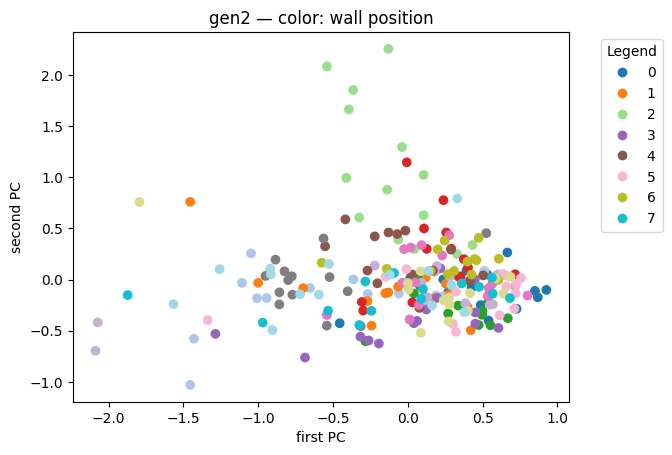

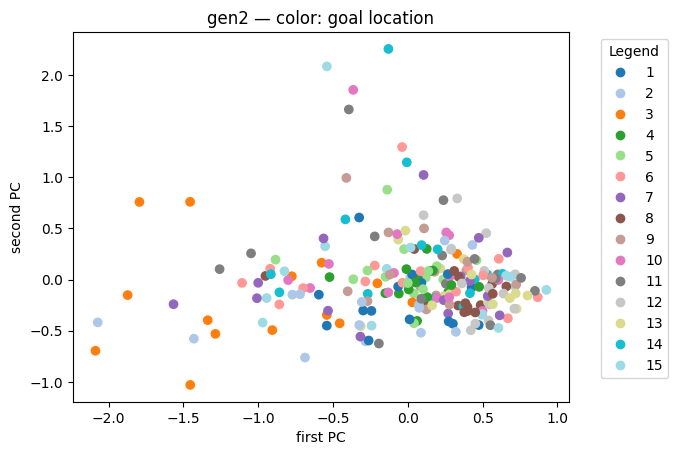


--- gen3 ---


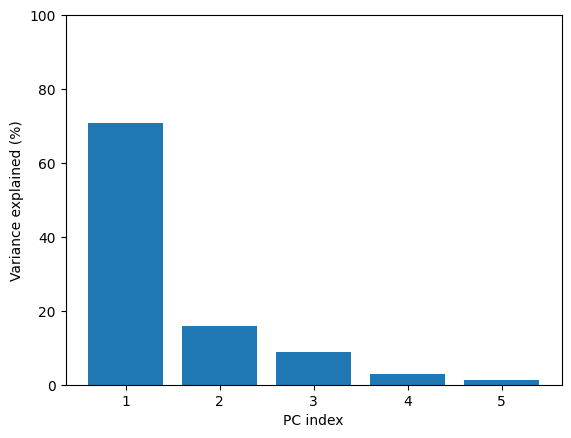

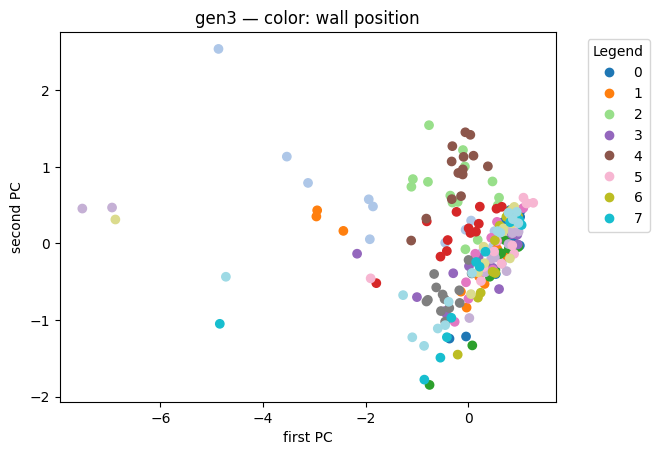

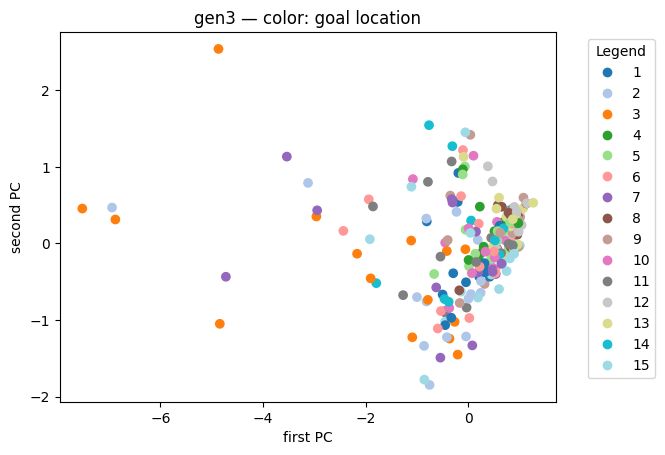


--- gen4 ---


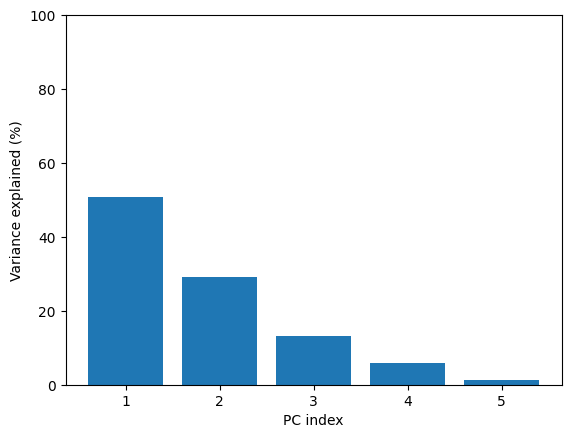

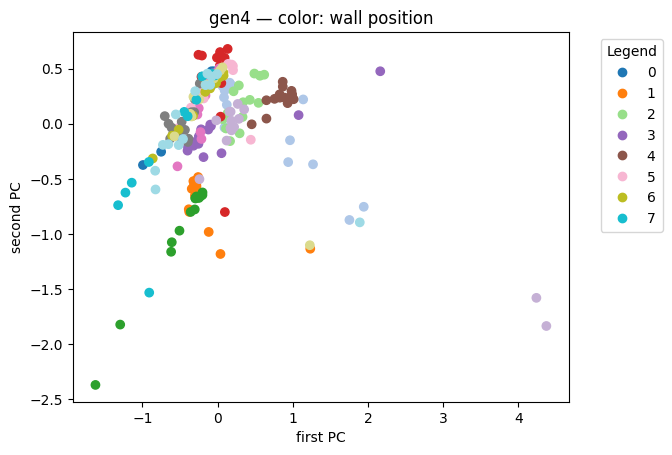

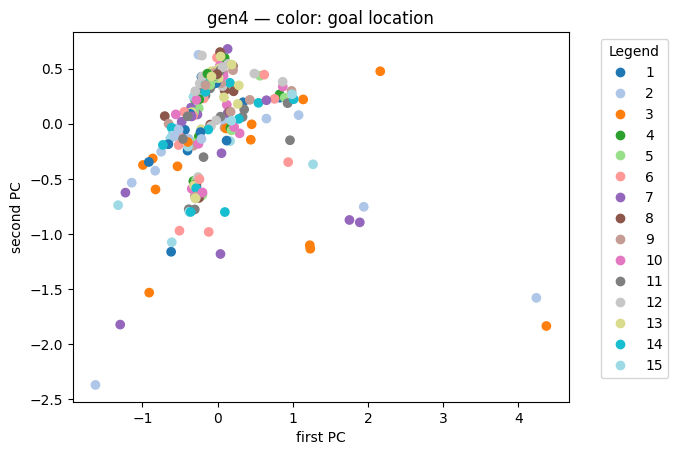


--- gen5 ---


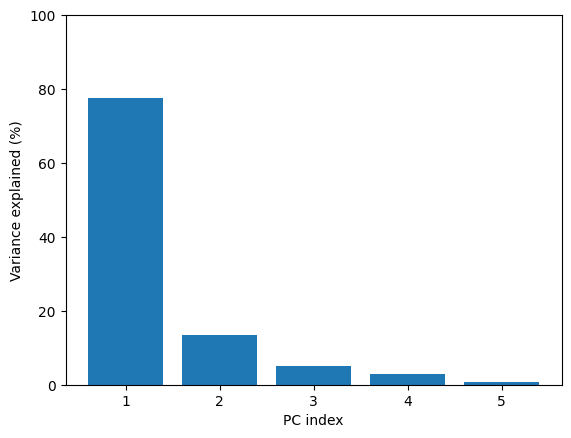

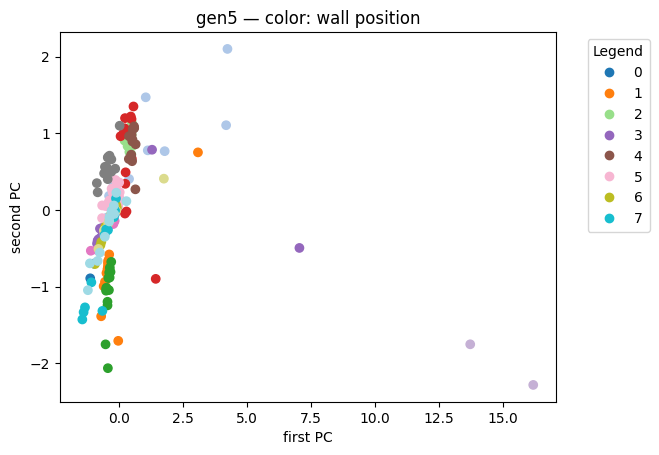

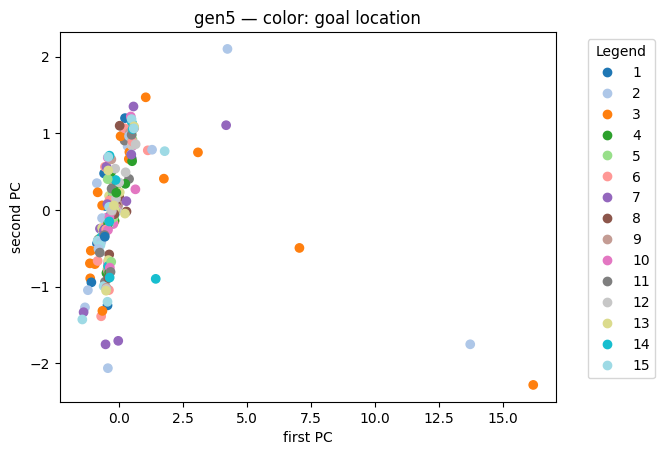

In [20]:
from sklearn.decomposition import PCA
from utils.plotting import plot_pca_variance, plot_pca_by_label

wall_labels = [label_dict[t][0] for t in label_dict]
goal_labels = [label_dict[t][2] for t in label_dict]

for gen_label, msgs in all_messages_by_gen.items():
    msgs_np = torch.stack(msgs).detach().cpu().numpy()
    pca = PCA(n_components=5)
    pca_result = pca.fit_transform(msgs_np)
    print(f"\n--- {gen_label} ---")
    plot_pca_variance(pca)
    plot_pca_by_label(pca_result, wall_labels, f"{gen_label} — color: wall position")
    plot_pca_by_label(pca_result, goal_labels, f"{gen_label} — color: goal location")

In [21]:
# Table 5: Critical F-values for variance analysis
from scipy.stats import f as f_dist
import os

# Degrees of freedom from variance_analyzer structure:
# N = 15 goal groups, M = 210 tasks (14 non-zero walls x 15 goals)
dfn = 14   # N - 1 (between-group)
dfd = 195  # M - N (within-group)

alphas = [0.1, 0.05, 0.01, 0.005, 0.001]

lines = [
    "Table 5 | Critical F-values for goal groupings (dfn=14, dfd=195)",
    "{:<20} {:>8}".format("Significance (a)", "F_crit"),
    "-" * 30,
]
for alpha in alphas:
    f_crit = f_dist.ppf(1 - alpha, dfn, dfd)
    lines.append("{:<20} {:>8.2f}".format(alpha, f_crit))

output = "\n".join(lines)
print(output)

# Save to file
_tbl_dir = os.path.join(os.path.abspath(''), '..', '..', '..', 'outputs', 'tables')
os.makedirs(_tbl_dir, exist_ok=True)
with open(os.path.join(_tbl_dir, 'table5_critical_f.txt'), 'w') as _f:
    _f.write(output + "\n")
print("\nSaved to outputs/tables/table5_critical_f.txt")

Table 5 | Critical F-values for goal groupings (dfn=14, dfd=195)
Significance (a)       F_crit
------------------------------
0.1                      1.54
0.05                     1.74
0.01                     2.17
0.005                    2.35
0.001                    2.74

Saved to outputs/tables/table5_critical_f.txt


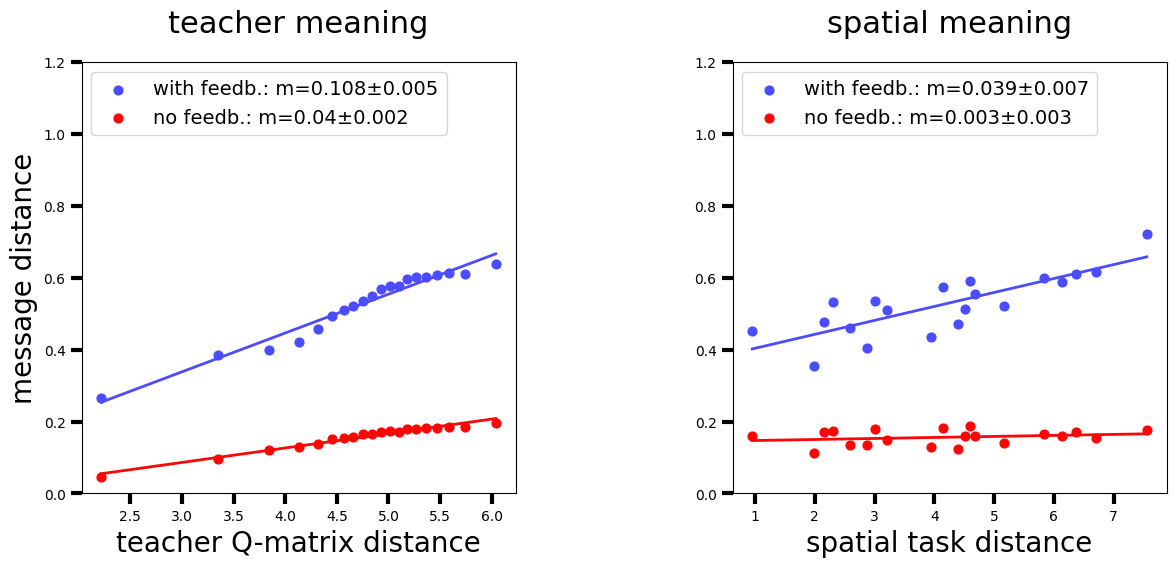

In [22]:
# Figure 3 (b, c) – Topographic Similarity
# Port of original notebook cell 23-24
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

norm_topo = config.norm_topo    # 2
n_bins    = config.n_bins_topo  # 20
w_goal    = config.goal_reward  # 2.0
w_wall    = config.wall_reward  # -0.5
grid_dim  = config.grid_dim     # 4
n_tasks   = len(label_dict)     # 225

# --- 1. State coordinate lookup (row, col); origin: bottom-left ---
# No-wall (wall_index=0) is placed outside the maze at (grid_dim, grid_dim)
state_coord = {i: np.array([i // grid_dim, i % grid_dim]) for i in range(grid_dim ** 2)}
state_coord[0] = np.array([grid_dim, grid_dim])

# --- 2. Weighted indicator vectors: [w_goal * goal_coord | w_wall * wall_coord] ---
tasks_list = [label_dict[t] for t in range(n_tasks)]
vwdict = {
    t: np.concatenate([w_goal * state_coord[gs], w_wall * state_coord[wi]])
    for t, (wi, _, gs) in enumerate(tasks_list)
}

# --- 3. Flat Q-matrices ---
qdict = {t: q_matrices[t].flatten().detach().numpy() for t in range(n_tasks)}

# --- 4. All lower-triangle pairs and their pairwise distances ---
pairs  = [(i, j) for i in range(n_tasks) for j in range(i + 1, n_tasks)]
qdist  = np.array([np.linalg.norm(qdict[i]  - qdict[j],  ord=norm_topo) for i, j in pairs])
vwdist = np.array([np.linalg.norm(vwdict[i] - vwdict[j], ord=norm_topo) for i, j in pairs])

# Sort pair indices by meaning distance for binning
q_sorted  = sorted(range(len(pairs)), key=lambda k: qdist[k])
vw_sorted = sorted(range(len(pairs)), key=lambda k: vwdist[k])

# --- 5. Convert message dicts from (wall,init,goal) key to task-index key ---
msg_nofb = {t: message_dict[tuple(label_dict[t])].detach().numpy()          for t in range(n_tasks)}
msg_fb   = {t: message_dict_feedback[tuple(label_dict[t])].detach().numpy() for t in range(n_tasks)}

# --- 6. Bin: average message dist per meaning-distance bin ---
def bin_topo(msg_by_task, sorted_keys, meaning_dist, n_bins):
    mdist = np.array([np.linalg.norm(msg_by_task[i] - msg_by_task[j]) for i, j in pairs])
    el = len(sorted_keys) // n_bins
    xvals, yvals = [], []
    for k in range(n_bins):
        chunk = sorted_keys[el * k: el * (k + 1)]
        xvals.append(np.mean(meaning_dist[chunk]))
        yvals.append(np.mean(mdist[chunk]))
    return np.array(xvals), np.array(yvals)

xq_nofb,  yq_nofb  = bin_topo(msg_nofb, q_sorted,  qdist,  n_bins)
xq_fb,    yq_fb    = bin_topo(msg_fb,   q_sorted,  qdist,  n_bins)
xvw_nofb, yvw_nofb = bin_topo(msg_nofb, vw_sorted, vwdist, n_bins)
xvw_fb,   yvw_fb   = bin_topo(msg_fb,   vw_sorted, vwdist, n_bins)

# --- 7. Plot (Figs. 3b, c) ---
def linfunc(x, m, b):
    return m * x + b

cmap_topo = plt.get_cmap("bwr")
fig, ax = plt.subplots(1, 2, figsize=(14, 5.6))

for j, (xnofb, ynofb, xfb, yfb, xlabel) in enumerate([
    (xq_nofb,  yq_nofb,  xq_fb,  yq_fb,  "teacher Q-matrix distance"),
    (xvw_nofb, yvw_nofb, xvw_fb, yvw_fb, "spatial task distance"),
]):
    for x, y, color, label in [
        (xfb,   yfb,   cmap_topo(0.15), "with feedb."),
        (xnofb, ynofb, cmap_topo(0.99), "no feedb."),
    ]:
        popt, pcov = curve_fit(linfunc, x, y)
        m_val = round(popt[0], 3)
        m_std = round(np.sqrt(np.diag(pcov))[0], 3)
        ax[j].scatter(x, y, color=color, s=40, label=f"{label}: m={m_val}\u00b1{m_std}")
        ax[j].plot(x, linfunc(x, *popt), color=color, lw=2)

    ax[j].set_xlabel(xlabel, fontsize=20)
    ax[j].legend(fontsize=14, loc=2)
    ax[j].set_ylim(0, 1.2)
    ax[j].tick_params(width=3, length=8)

ax[0].set_ylabel("message distance", fontsize=20)
ax[0].set_title("teacher meaning", fontsize=22, y=1.05)
ax[1].set_title("spatial meaning",  fontsize=22, y=1.05)
plt.subplots_adjust(wspace=0.5)

os.makedirs(os.path.join(os.path.abspath(''), '..', '..', '..', 'outputs', 'figures'), exist_ok=True)
_fig_dir = os.path.join(os.path.abspath(''), '..', '..', '..', 'outputs', 'figures')
plt.savefig(os.path.join(_fig_dir, 'fig3_bc_topographic_similarity.png'), bbox_inches='tight', dpi=150)
plt.show()

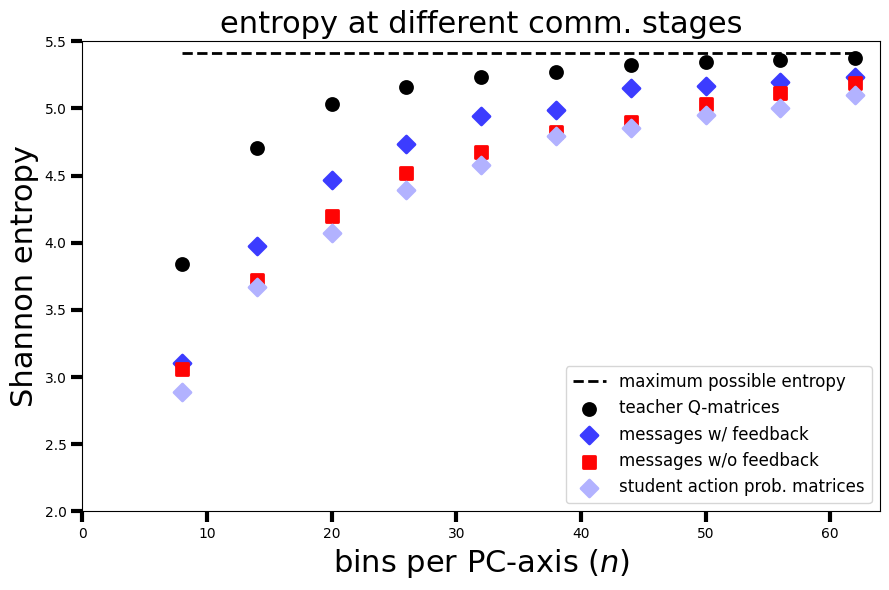

In [24]:
# Figure 3 (d, e) – Shannon Entropy Analysis
# Port of original notebook cells 25-26
import scipy.stats as sp_stats
from sklearn.decomposition import PCA
import torch.nn as nn
from rl.teacher import q_matrix_from_network

H_binlist = config.H_binlist   # e.g. [8, 13, 19, ..., 62]
softy = nn.Softmax(dim=0)

def get_2D_PCA_entropy(input_array, n_bins, method="B"):
    """Project to 2D PCA, histogram, compute Shannon entropy."""
    pca = PCA(n_components=2)
    proj = pca.fit_transform(input_array)
    xv, yv = proj[:, 0], proj[:, 1]
    if method == "A":
        hist, _, _ = np.histogram2d(xv, yv, bins=n_bins)
    else:  # method B: equal-extent square
        delta = max(xv.max() - xv.min(), yv.max() - yv.min()) / 2
        xmid  = (xv.max() + xv.min()) / 2
        ymid  = (yv.max() + yv.min()) / 2
        hist, _, _ = np.histogram2d(xv, yv, bins=n_bins,
                                    range=[[xmid - delta, xmid + delta],
                                           [ymid - delta, ymid + delta]])
    hist = hist.flatten() / hist.sum()
    return sp_stats.entropy(hist)

# --- 1. Teacher Q-matrices (flat numpy) ---
q_teacher_arr = np.array([q_matrices[t].flatten().detach().numpy() for t in range(n_tasks)])

# --- 2. Messages: no-feedback and with-feedback ---
msg_nofb_arr = np.array([message_dict[tuple(label_dict[t])].detach().numpy()          for t in range(n_tasks)])
msg_fb_arr   = np.array([message_dict_feedback[tuple(label_dict[t])].detach().numpy() for t in range(n_tasks)])

# --- 3. Student Q-matrices and probability matrices (feedback student) ---
student.eval()
autoencoder.eval()
q_student_list, p_student_list = [], []
with torch.no_grad():
    for t in range(n_tasks):
        wi, _, gs = label_dict[t]
        msg    = message_dict_feedback[tuple(label_dict[t])].to(device)
        wall_s = wall_state_dict[wi]
        env    = make_gridworld_env(label_dict[t], wall_state_dict, config)
        q_mat  = q_matrix_from_network(student, msg, wall_s, config, device, env).cpu()
        q_student_list.append(q_mat.flatten().numpy())
        p_student_list.append(softy(q_mat.flatten()).numpy())
q_student_arr = np.array(q_student_list)
p_student_arr = np.array(p_student_list)

# --- 4. Entropy across bin sizes (method B = equal extent, as in original) ---
H_q_teacher = np.array([get_2D_PCA_entropy(q_teacher_arr, n) for n in H_binlist])
H_msg_nofb  = np.array([get_2D_PCA_entropy(msg_nofb_arr,  n) for n in H_binlist])
H_msg_fb    = np.array([get_2D_PCA_entropy(msg_fb_arr,    n) for n in H_binlist])
H_p_student = np.array([get_2D_PCA_entropy(p_student_arr, n) for n in H_binlist])

# --- 5. Plot (Fig. 3e) ---
Hmax = sp_stats.entropy([1 / n_tasks] * n_tasks)  # log(225) ≈ 5.42
cmap_ent = plt.get_cmap("bwr")

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot([H_binlist[0], H_binlist[-1]], [Hmax, Hmax],
        ls="--", color="black", label="maximum possible entropy", lw=2)

entries = [
    (H_q_teacher, "black",         "o", "teacher Q-matrices"),
    (H_msg_fb,    cmap_ent(0.12),  "D", "messages w/ feedback"),
    (H_msg_nofb,  cmap_ent(0.99),  "s", "messages w/o feedback"),
    (H_p_student, cmap_ent(0.35),  "D", "student action prob. matrices"),
]
for H, color, marker, label in entries:
    ax.scatter(H_binlist, H, color=color, marker=marker, s=75, label=label, lw=2)

ax.set_xlabel(r"bins per PC-axis ($\it{n}$)", fontsize=22)
ax.set_ylabel("Shannon entropy", fontsize=22)
ax.set_title("entropy at different comm. stages", fontsize=22)
ax.set_xlim(0, 64)
ax.set_ylim(2, 5.5)
ax.legend(fontsize=12, loc=4)
ax.tick_params(width=3, length=8)
fig.tight_layout()

os.makedirs(os.path.join(os.path.abspath(''), '..', '..', '..', 'outputs', 'figures'), exist_ok=True)
_fig_dir = os.path.join(os.path.abspath(''), '..', '..', '..', 'outputs', 'figures')
plt.savefig(os.path.join(_fig_dir, 'fig3_de_entropy.png'), bbox_inches='tight', dpi=150)
plt.show()